# XGBoost Modelling Pipeline

## 1. Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
from scipy.stats import randint, uniform


## 2. Global Configurations

In [2]:
# Which GSADF label column to use as the prediction target:
#   "gsadf_label_95"  →  95% confidence interval (stricter bubble detection)
#   "gsadf_label_90"  →  90% confidence interval (more sensitive)
TARGET_COL = "gsadf_label_90"

# Columns that are NOT model features are dropped before training
NON_FEATURE_COLS = [
    "date",
    "symbol",
    "fear_greed_classification",
    "gsadf_label_95",
    "gsadf_label_90",
]

# String → integer label mapping
LABEL_STR_TO_INT = {
    "Not Bubble"      : 0,
    "Bubble Creation" : 1,
    "Bubble Collapse" : 2,
}
LABEL_MAP   = {v: k for k, v in LABEL_STR_TO_INT.items()}
CLASS_NAMES = ["Not Bubble", "Bubble Creation", "Bubble Collapse"]

# Fear & Greed text → ordinal integer feature
SENTIMENT_ORDINAL = {
    "Extreme Fear" : 0,
    "Fear"         : 1,
    "Neutral"      : 2,
    "Greed"        : 3,
    "Extreme Greed": 4,
}

COLORS     = ["#4C72B0", "#DD8452", "#55A868"]
OUTPUT_DIR = "xgboost_stats_fixed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "monospace",
})


## 3. Loading & Preprocessing Data

In [3]:
def load_and_preprocess(filepath: str) -> pd.DataFrame:
    """
    Load CSV, encode sentiment, impute missing values, remove infinities,
    and create the lead label (predict TOMORROW's bubble state).
    """
    df = pd.read_csv(filepath, parse_dates=["date"])
    df.sort_values(["date", "symbol"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f"Loaded {len(df):,} rows | Symbols: {sorted(df['symbol'].unique())} "
          f"| {df['date'].min().date()} → {df['date'].max().date()}")

    # Encode fear_greed_classification as ordinal numeric feature
    df["sentiment_ordinal"] = df["fear_greed_classification"].map(SENTIMENT_ORDINAL)
    df["sentiment_ordinal"].fillna(2, inplace=True)

    # Impute missing numeric values (ffill/bfill per coin, then global median)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df[numeric_cols] = (
        df.groupby("symbol")[numeric_cols]
        .transform(lambda g: g.ffill().bfill())
    )
    for col in numeric_cols:
        if df[col].isna().any():
            df[col].fillna(df[col].median(), inplace=True)

    # Replace +/- inf with column median
    inf_mask = np.isinf(df[numeric_cols])
    if inf_mask.any(axis=None):
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        for col in numeric_cols:
            if df[col].isna().any():
                df[col].fillna(df[col].median(), inplace=True)

    # Clip extreme outliers
    df[numeric_cols] = df[numeric_cols].clip(lower=-1e15, upper=1e15)

    # Create lead label: each row's target = TOMORROW's bubble state
    LEAD_COL = TARGET_COL + "_lead"
    df[LEAD_COL] = df.groupby("symbol")[TARGET_COL].shift(-1)
    df.dropna(subset=[LEAD_COL], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Encode string labels → integers
    df["bubble_label"] = df[LEAD_COL].map(LABEL_STR_TO_INT)
    if df["bubble_label"].isna().any():
        raise ValueError(
            f"Unmapped labels found in '{LEAD_COL}': {df[LEAD_COL].unique().tolist()}"
        )
    df["bubble_label"] = df["bubble_label"].astype(int)

    counts = df["bubble_label"].value_counts().sort_index().rename(LABEL_MAP)
    print(f"Label distribution:\n{counts.to_string()}\n")
    return df


def split_features_target(df: pd.DataFrame):
    
    """
    Drop non-feature columns and return (X, y).
    """
    
    drop_cols = NON_FEATURE_COLS + ["bubble_label", TARGET_COL + "_lead"]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df["bubble_label"]

    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        raise ValueError(f"Non-numeric columns in X: {non_numeric}")
    return X, y


## 4. Train/Test Split

The data is split **chronologically**, so all rows before the cutoff date form the training set; all rows from the cutoff onward form the test set. Random splitting would leak future information into training, inflating apparent model accuracy.

In [4]:
def temporal_train_test_split(df: pd.DataFrame, test_ratio: float = 0.2):
    
    """
    Chronological train/test split on the unique date axis.
    All coins are cut at the same calendar date to avoid cross-coin leakage.
    """
    
    unique_dates = sorted(df["date"].unique())
    cutoff_idx   = int(len(unique_dates) * (1 - test_ratio))
    cutoff_date  = unique_dates[cutoff_idx]

    df_train = df[df["date"] <  cutoff_date].copy()
    df_test  = df[df["date"] >= cutoff_date].copy()

    X_train, y_train = split_features_target(df_train)
    X_test,  y_test  = split_features_target(df_test)

    print(f"Cut-off: {pd.Timestamp(cutoff_date).date()} | "
          f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
    return X_train, X_test, y_train, y_test, df_train, df_test


## 5. SMOTE
Due to the extreme difference in the counts of the differemt classes, as suggested we will implement SMOTE for class imbalance handling.

In [5]:
def apply_smote(X_train: pd.DataFrame, y_train: pd.Series,
               random_state: int = 42, verbose: bool = False):
    
    """
    Oversample minority classes on the training set only.
    k_neighbors is capped at (minority_class_size - 1) to avoid crashes.
    """
    
    X_arr = np.array(X_train)
    if np.any(np.isinf(X_arr)):
        raise ValueError("Infinity values in X_train — re-run load_and_preprocess().")
    if np.any(np.isnan(X_arr)):
        raise ValueError("NaN values in X_train — re-run load_and_preprocess().")

    min_count = y_train.value_counts().min()
    k = max(1, min(5, min_count - 1))

    smote = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = smote.fit_resample(X_train, y_train)

    if verbose:
        before = y_train.value_counts().sort_index().rename(LABEL_MAP)
        after  = pd.Series(y_res).value_counts().sort_index().rename(LABEL_MAP)
        print(f"SMOTE  Before: {before.to_dict()}  →  After: {after.to_dict()}")
    return X_res, y_res


## 6. XGBoost Model

In [6]:
def build_baseline_xgboost(random_state: int = 42) -> xgb.XGBClassifier:
    """XGBoost classifier with sensible defaults for 3-class bubble prediction."""
    return xgb.XGBClassifier(
        objective        = "multi:softprob",
        num_class        = 3,
        n_estimators     = 300,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        gamma            = 0.1,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        eval_metric      = "mlogloss",
        random_state     = random_state,
        n_jobs           = -1,
    )


def hyperparameter_tuning(
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_iter:       int = 40,
    cv_folds:     int = 5,
    random_state: int = 42,
) -> xgb.XGBClassifier:
    """
    Randomised search over XGBoost hyperparameters.
    Scored by macro F1 — treats all three bubble classes equally.
    Uses StratifiedKFold to ensure all classes appear in every fold.
    """
    param_distributions = {
        "n_estimators"     : randint(100, 600),
        "max_depth"        : randint(3, 10),
        "learning_rate"    : uniform(0.01, 0.2),
        "subsample"        : uniform(0.6, 0.4),
        "colsample_bytree" : uniform(0.5, 0.5),
        "min_child_weight" : randint(1, 15),
        "gamma"            : uniform(0, 0.5),
        "reg_alpha"        : uniform(0, 1.0),
        "reg_lambda"       : uniform(0.5, 2.0),
    }

    base_model = xgb.XGBClassifier(
        objective    = "multi:softprob",
        num_class    = 3,
        eval_metric  = "mlogloss",
        random_state = random_state,
        n_jobs       = -1,
    )

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        estimator           = base_model,
        param_distributions = param_distributions,
        n_iter              = n_iter,
        scoring             = "f1_macro",
        cv                  = cv,
        verbose             = 0,
        random_state        = random_state,
        n_jobs              = -1,
        refit               = True,
    )

    search.fit(X_train, y_train)
    print(f"  Best CV macro-F1 : {search.best_score_:.4f}")
    return search.best_estimator_


# ── FIX 1: Carve a held-out validation set from the TRAINING data for
#           early stopping instead of using the test set.
#           Using the test set as the eval_set leaks test information
#           into the training loop and inflates reported performance,
#           especially for per-coin models whose test sets are small
#           and homogeneous — making early stopping overfit aggressively
#           to those specific test distributions. ──
def train_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model:   xgb.XGBClassifier,
    val_ratio: float = 0.1,
    random_state: int = 42,
) -> xgb.XGBClassifier:
    """
    Fit XGBoost with early stopping (30 rounds patience).

    A small stratified validation split is carved from the TRAINING data
    so that the test set is never seen during fitting.
    """
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train,
        test_size    = val_ratio,
        stratify     = y_train,
        random_state = random_state,
    )
    model.set_params(early_stopping_rounds=30)
    model.fit(
        X_tr, y_tr,
        eval_set = [(X_val, y_val)],
        verbose  = False,
    )
    return model


## 7. Evaluation & Visualisations

In [7]:
def evaluate_model(
    model:      xgb.XGBClassifier,
    X_test:     pd.DataFrame,
    y_test:     pd.Series,
    model_name: str = "XGBoost",
) -> dict:
    
    """
    Compute per-class Precision, Recall, F1 plus Macro F1, Weighted F1,
    and ROC-AUC. Prints a clean classification report.

    Handles the case where the test set does not contain all 3 classes
    (common in per-coin evaluation) by:
      - Padding per-class metric arrays to length 3 with zeros for absent classes
      - Computing ROC-AUC only over the classes that are present in y_test,
        or reporting NaN when fewer than 2 classes are present
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)      # always shape (n_samples, 3)

    present_classes = sorted(y_test.unique())   # which class integers appear in y_test
    n_present       = len(present_classes)

    # Per-class metrics which are padded to length 3 
    # sklearn returns one value per class that actually appears in y_test/y_pred.
    # We reindex to the full [0, 1, 2] space so downstream code always sees 3 values.
    # ── FIX 2: Always pass labels=[0,1,2] so sklearn returns exactly 3 values
    #           in a fixed order. Without this, if y_pred predicts a class
    #           absent from y_test, sklearn inserts an extra position and the
    #           positional mapping shifts, silently swapping metric values. ──
    def _padded(metric_fn, **kwargs):
        raw = metric_fn(y_test, y_pred, average=None, zero_division=0,
                        labels=[0, 1, 2], **kwargs)
        return raw  # already length-3, one entry per class

    precision_pc = _padded(precision_score)
    recall_pc    = _padded(recall_score)
    f1_pc        = _padded(f1_score)

    f1_macro     = f1_score(       y_test, y_pred, average="macro",    zero_division=0)
    f1_weighted  = f1_score(       y_test, y_pred, average="weighted", zero_division=0)
    prec_macro   = precision_score(y_test, y_pred, average="macro",    zero_division=0)
    rec_macro    = recall_score(   y_test, y_pred, average="macro",    zero_division=0)

    # ROC-AUC — only computable when ≥ 2 classes are present 
    # roc_auc_score(multi_class="ovr") requires the number of unique classes in
    # y_true to equal the number of columns in y_score. We slice y_prob to only
    # the columns that correspond to classes actually present in the test set.
    if n_present >= 2:
        y_prob_present = y_prob[:, present_classes]   # keep only relevant columns
        if n_present == 3:
            # All classes present — standard multiclass OvR
            roc_auc = roc_auc_score(
                y_test, y_prob_present, multi_class="ovr", average="weighted")
        else:
            # Exactly 2 classes present — binary ROC-AUC on the positive column
            # Re-label y_test to 0/1 for the two present classes
            y_bin     = (y_test == present_classes[1]).astype(int)
            roc_auc   = roc_auc_score(y_bin, y_prob_present[:, 1])
    else:
        # Only 1 class in test set — ROC-AUC is undefined
        roc_auc = float("nan")

    print("=" * 60)
    print(f"  {model_name}")
    if n_present < 3:
        print(f"  ⚠ Only {n_present} class(es) in test set: "
              f"{[CLASS_NAMES[c] for c in present_classes]}")
    print("=" * 60)
    print(classification_report(
        y_test, y_pred, target_names=CLASS_NAMES, digits=4,
        zero_division=0, labels=[0, 1, 2]))
    roc_str = f"{roc_auc:.4f}" if not np.isnan(roc_auc) else "N/A"
    print(f"  Macro F1   : {f1_macro:.4f}   |   "
          f"Weighted F1 : {f1_weighted:.4f}   |   "
          f"ROC-AUC : {roc_str}")
    print("=" * 60 + "\n")

    return {
        "model_name"         : model_name,
        "y_pred"             : y_pred,
        "y_prob"             : y_prob,
        "precision_per_class": precision_pc,
        "recall_per_class"   : recall_pc,
        "f1_per_class"       : f1_pc,
        "f1_macro"           : f1_macro,
        "f1_weighted"        : f1_weighted,
        "precision_macro"    : prec_macro,
        "recall_macro"       : rec_macro,
        "roc_auc"            : roc_auc,
    }

# Plotting the statistics 
def plot_confusion_matrix(y_test, y_pred, model_name: str = "XGBoost"):

    """
    Normalised confusion matrix (values = proportions of true class).
    """
    cm   = confusion_matrix(y_test, y_pred, normalize="true", labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=True, cmap="Blues", values_format=".2f")
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=12, pad=10)
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f"cm_{model_name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_per_class_metrics(results: dict):

    """
    Grouped bar chart: Precision / Recall / F1 per bubble class.
    """
    metrics = {
        "Precision": results["precision_per_class"],
        "Recall"   : results["recall_per_class"],
        "F1-Score" : results["f1_per_class"],
    }
    x, width = np.arange(len(CLASS_NAMES)), 0.25
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (name, vals) in enumerate(metrics.items()):
        bars = ax.bar(x + i * width, vals, width, label=name, color=COLORS[i], alpha=0.85)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"Per-Class Metrics — {results['model_name']}", fontsize=12)
    ax.legend(loc="upper right")
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR,
                         f"metrics_{results['model_name'].replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_feature_importance(model: xgb.XGBClassifier, model_name: str = "XGBoost",
                             top_n: int = 20):
    
    """
    Horizontal bar chart of top features ranked by gain.
    """
    importance = model.get_booster().get_score(importance_type="gain")
    imp_df = (
        pd.DataFrame.from_dict(importance, orient="index", columns=["Gain"])
        .rename_axis("Feature").reset_index()
        .sort_values("Gain", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, top_n * 0.38 + 1))
    ax.barh(imp_df["Feature"][::-1], imp_df["Gain"][::-1], color="#4C72B0", alpha=0.85)
    ax.set_xlabel("Gain")
    ax.set_title(f"Top {top_n} Features by Gain — {model_name}", fontsize=12)
    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR,
                         f"feature_importance_{model_name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_class_distribution(y_before, y_after, title_suffix: str = ""):

    """
    Side-by-side bar charts: class counts before vs after SMOTE.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, y, title in zip(axes,
                             [y_before, y_after],
                             ["Before SMOTE", "After SMOTE"]):
        counts = pd.Series(y).value_counts().sort_index().rename(LABEL_MAP)
        ax.bar(range(len(counts)), counts.values, color=COLORS, alpha=0.85, edgecolor="white")
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=10, ha="right")
        ax.set_title(f"{title}{title_suffix}", fontsize=11)
        ax.set_ylabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    safe = title_suffix.strip().replace(" ", "_").replace("/", "")
    fname = os.path.join(OUTPUT_DIR, f"smote_distribution{safe}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


# Functions for exporting results to CSV and plotting metrics are defined below.
def export_metrics_to_csv(results_list: list, filepath: str = None):

    """
    Write per-class and aggregate metrics for all models to CSV.
    """
    if filepath is None:
        filepath = os.path.join(OUTPUT_DIR, "model_metrics_summary.csv")
    rows = []
    for r in results_list:
        for i, cls in enumerate(CLASS_NAMES):
            rows.append({
                "Model"    : r["model_name"],
                "Class"    : cls,
                "Precision": round(r["precision_per_class"][i], 4),
                "Recall"   : round(r["recall_per_class"][i],    4),
                "F1-Score" : round(r["f1_per_class"][i],        4),
            })
        roc_val = r["roc_auc"]
        roc_display = round(roc_val, 4) if not np.isnan(roc_val) else "N/A"
        for label, val in [
            ("-- MACRO AVG --",          r["f1_macro"]),
            ("-- WEIGHTED AVG (F1) --",  r["f1_weighted"]),
        ]:
            rows.append({"Model": r["model_name"], "Class": label,
                         "Precision": "--", "Recall": "--",
                         "F1-Score": round(val, 4)})
        rows.append({"Model": r["model_name"], "Class": "-- ROC-AUC (weighted) --",
                     "Precision": "--", "Recall": "--", "F1-Score": roc_display})
    df_out = pd.DataFrame(rows)
    df_out.to_csv(filepath, index=False)
    print(f"Metrics saved → {filepath}")
    return df_out


## 8. Cross-Asset Analysis
We further train xgboost models for each individual coin to validate the validity of the theory given. 


In [8]:
def evaluate_per_coin(model: xgb.XGBClassifier,
                      df_test: pd.DataFrame,
                      model_name: str = "Global Model") -> pd.DataFrame:
    
    """
    Evaluate a trained model separately for each coin in the test set.
    Returns a DataFrame of per-coin F1 scores.
    """
    rows = []
    for coin in sorted(df_test["symbol"].unique()):
        subset = df_test[df_test["symbol"] == coin].copy()
        X_coin, y_coin = split_features_target(subset)
        y_pred = model.predict(X_coin)

        f1s = f1_score(y_coin, y_pred, average=None, zero_division=0)
        f1s = np.pad(f1s, (0, max(0, 3 - len(f1s))))
        rows.append({
            "Coin"             : coin,
            "F1 Not Bubble"    : round(f1s[0], 4),
            "F1 Bubble Creat." : round(f1s[1], 4),
            "F1 Bubble Coll."  : round(f1s[2], 4),
            "F1 Weighted"      : round(
                f1_score(y_coin, y_pred, average="weighted", zero_division=0), 4),
        })

    df_coins = pd.DataFrame(rows)
    df_coins.to_csv(
        os.path.join(OUTPUT_DIR, f"per_coin_f1_{model_name.replace(' ', '_')}.csv"),
        index=False)
    return df_coins


def train_per_coin_models(
    df: pd.DataFrame,
    test_ratio:   float = 0.2,
    n_iter:       int   = 40,
    cv_folds:     int   = 5,
    random_state: int   = 42,
) -> tuple:
    
    """
    Train a separate hyperparameter-tuned XGBoost model for each coin.

    For each symbol the function:
      1. Filters the data to that coin only
      2. Performs a chronological train/test split
      3. Applies SMOTE to the training set
      4. Runs hyperparameter tuning (macro F1 scoring)
      5. Trains the best model with early stopping
      6. Evaluates on the coin's test set

    Returns
    -------
    per_coin_models  : dict  {symbol → fitted XGBClassifier}
    per_coin_results : dict  {symbol → evaluate_model() result dict}
    summary_df       : pd.DataFrame  with per-coin metrics
    """
    coins            = sorted(df["symbol"].unique())
    per_coin_models  = {}
    per_coin_results = {}
    summary_rows     = []

    for coin in coins:
        print(f"\n{'─'*55}")
        print(f"  Training per-coin model : {coin}")
        print(f"{'─'*55}")

        coin_df = df[df["symbol"] == coin].copy().reset_index(drop=True)

        # Chronological split within this coin's data
        unique_dates = sorted(coin_df["date"].unique())
        cutoff_idx   = int(len(unique_dates) * (1 - test_ratio))
        cutoff_date  = unique_dates[cutoff_idx]

        train_df = coin_df[coin_df["date"] <  cutoff_date].copy()
        test_df  = coin_df[coin_df["date"] >= cutoff_date].copy()

        X_train, y_train = split_features_target(train_df)
        X_test,  y_test  = split_features_target(test_df)

        print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}  "
              f"| Cut-off: {pd.Timestamp(cutoff_date).date()}")

        # Skip coin if any class is absent from training set (can't SMOTE or tune)
        if y_train.nunique() < 3:
            print(f"  ⚠ Skipping {coin}: fewer than 3 classes in training set.")
            continue

        # SMOTE
        X_tr_res, y_tr_res = apply_smote(X_train, y_train,
                                          random_state=random_state, verbose=True)

        # Hyperparameter tuning
        model = hyperparameter_tuning(X_tr_res, y_tr_res,
                                       n_iter=n_iter, cv_folds=cv_folds,
                                       random_state=random_state)

        # Train with early stopping on a held-out val split (not the test set)
        model = train_model(X_tr_res, y_tr_res, model)

        # Evaluate
        result = evaluate_model(model, X_test, y_test, f"Per-Coin: {coin}")

        per_coin_models[coin]  = model
        per_coin_results[coin] = result

        for i, cls in enumerate(CLASS_NAMES):
            summary_rows.append({
                "Coin"      : coin,
                "Class"     : cls,
                "Precision" : round(result["precision_per_class"][i], 4),
                "Recall"    : round(result["recall_per_class"][i],    4),
                "F1-Score"  : round(result["f1_per_class"][i],        4),
            })
        summary_rows.append({
            "Coin": coin, "Class": "-- MACRO AVG --",
            "Precision": "--", "Recall": "--",
            "F1-Score": round(result["f1_macro"], 4),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(
        os.path.join(OUTPUT_DIR, "per_coin_model_metrics.csv"), index=False)
    print(f"\nPer-coin model metrics saved → xgboost_stats/per_coin_model_metrics.csv")
    return per_coin_models, per_coin_results, summary_df


def plot_per_coin_heatmap(df_coins: pd.DataFrame, title: str = ""):
    
    """
    Heatmap of F1 scores across coins and bubble states.
    Expects a DataFrame with columns: "Coin", "F1 Not Bubble", "F1 Bubble Creat.", "F1 Bubble Coll."
    """
    heat_df = df_coins.set_index("Coin")[
        ["F1 Not Bubble", "F1 Bubble Creat.", "F1 Bubble Coll."]
    ]
    fig, ax = plt.subplots(figsize=(7, len(df_coins) * 0.6 + 1.5))
    sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="YlGnBu",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"F1 Score by Coin & Bubble State{(' — ' + title) if title else ''}",
                 fontsize=12)
    plt.tight_layout()
    safe = title.replace(" ", "_")
    fname = os.path.join(OUTPUT_DIR, f"per_coin_heatmap_{safe}.png")
    plt.savefig(fname, dpi=130)
    plt.show()


def plot_per_coin_model_comparison(per_coin_results: dict):
    
    """
    Bar chart comparing macro F1 of each coin's dedicated model.
    """
    coins  = list(per_coin_results.keys())
    f1s    = [per_coin_results[c]["f1_macro"] for c in coins]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(coins, f1s, color="#4C72B0", alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Macro F1")
    ax.set_title("Per-Coin Model — Macro F1 by Coin", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "per_coin_macro_f1_bar.png"), dpi=130)
    plt.show()


## 9. Main Pipeline

Runs two model types in sequence:
- **Model 1 — Global**: one XGBoost model trained on all coins together
- **Model 2 — Per-Coin**: one separate XGBoost model per coin

  DSE4211 GROUP 18 — XGBoost Bubble Prediction Pipeline

Loaded 13,365 rows | Symbols: ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL'] | 2018-05-01 → 2025-01-01
Label distribution:
bubble_label
Not Bubble         10432
Bubble Creation     2001
Bubble Collapse      926


  MODEL 1 — GLOBAL (all coins combined)
Cut-off: 2023-09-01 | Train: 10,431 rows | Test: 2,928 rows


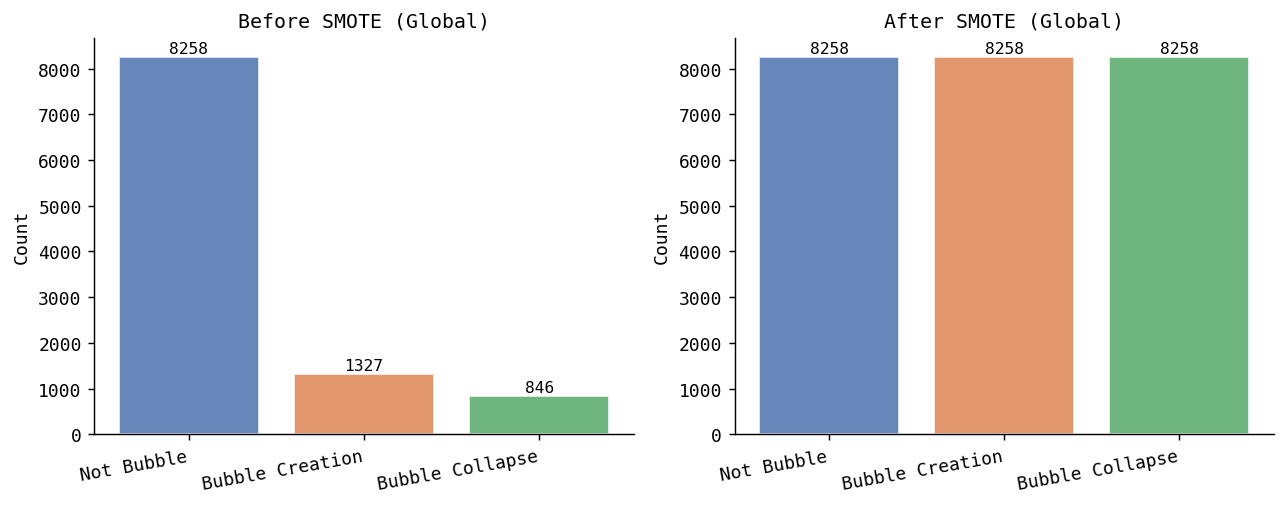


Hyperparameter tuning — Global model...
  Best CV macro-F1 : 0.9914
  Global XGBoost
                 precision    recall  f1-score   support

     Not Bubble     0.7427    0.9995    0.8522      2174
Bubble Creation     0.0000    0.0000    0.0000       674
Bubble Collapse     0.5000    0.0125    0.0244        80

       accuracy                         0.7425      2928
      macro avg     0.4142    0.3373    0.2922      2928
   weighted avg     0.5651    0.7425    0.6334      2928

  Macro F1   : 0.2922   |   Weighted F1 : 0.6334   |   ROC-AUC : 0.7901



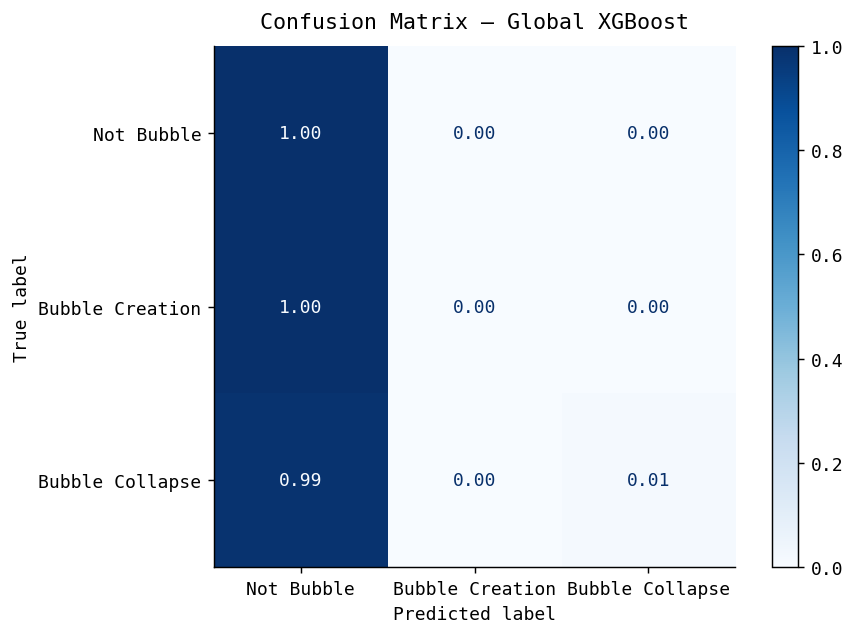

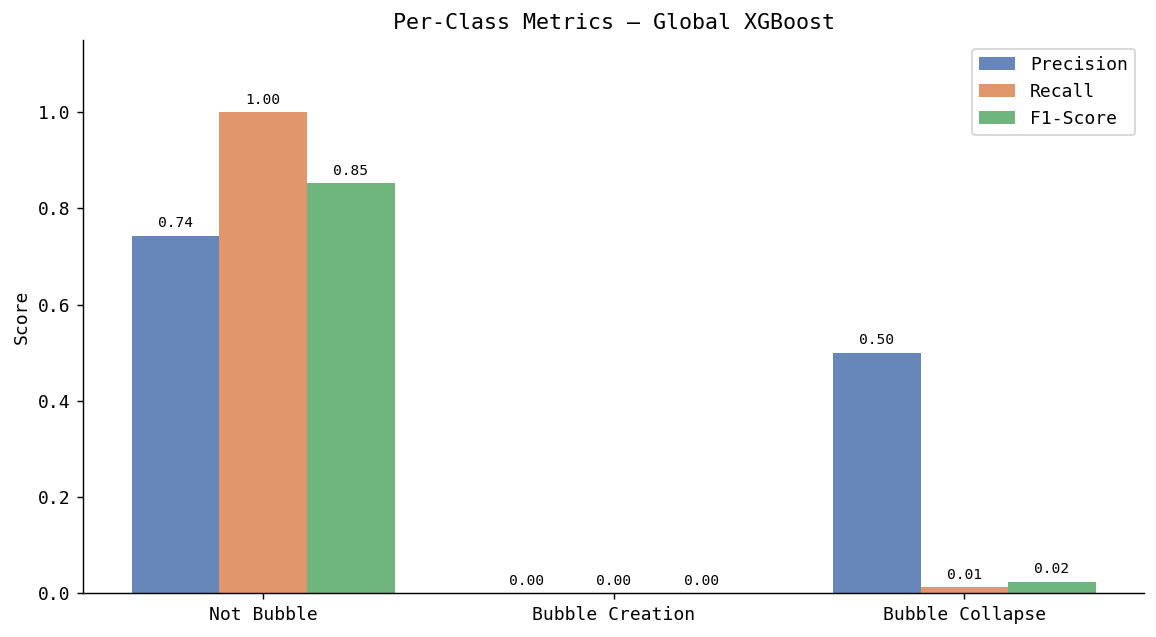

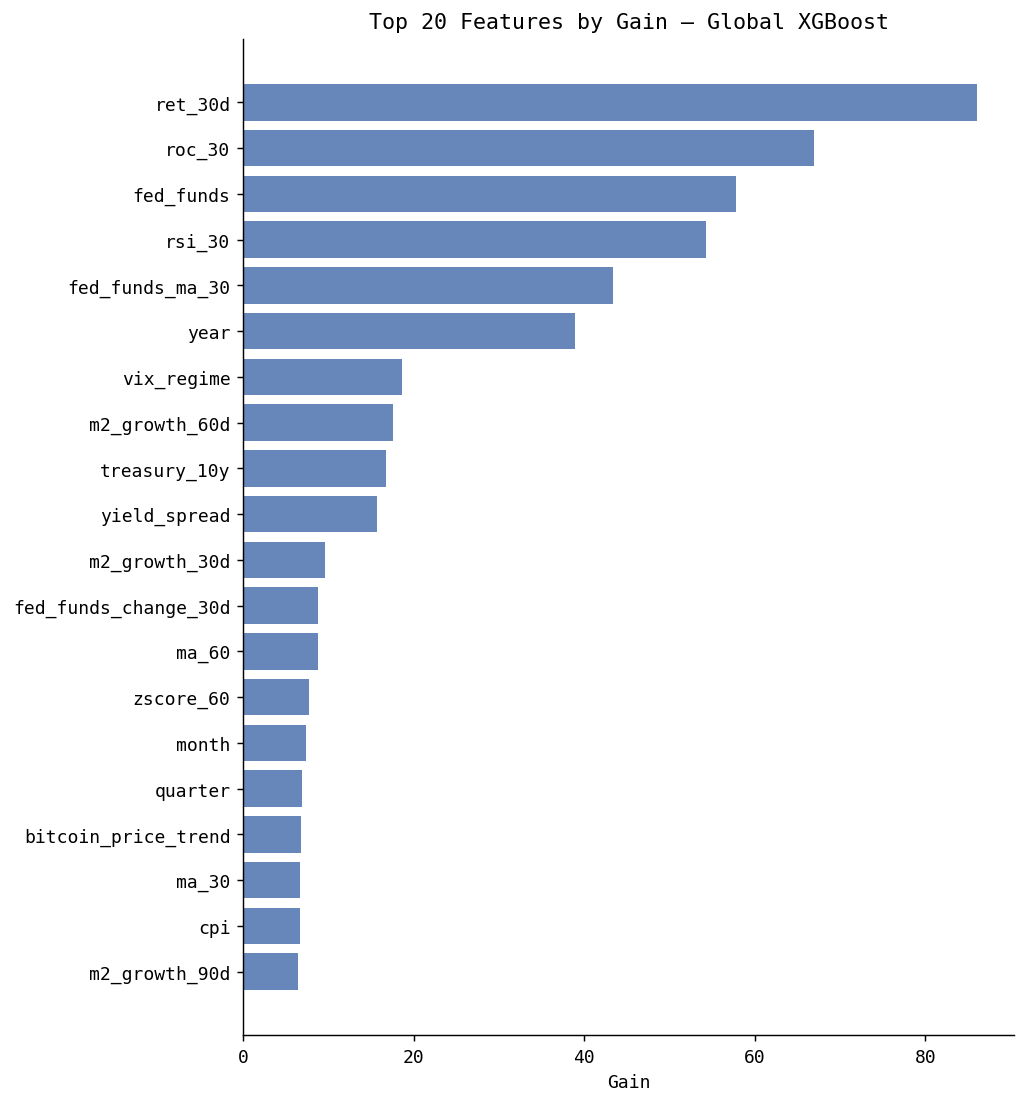


Global model — per-coin breakdown:
Coin  F1 Not Bubble  F1 Bubble Creat.  F1 Bubble Coll.  F1 Weighted
 ADA         0.9083               0.0           0.0000       0.7557
 BNB         0.8504               0.0           0.0000       0.6291
 BTC         0.7630               0.0           0.0000       0.4706
DOGE         0.9009               0.0           0.0000       0.7384
 ETH         0.9357               0.0           0.0000       0.8225
 SOL         0.7235               0.0           0.0571       0.4145


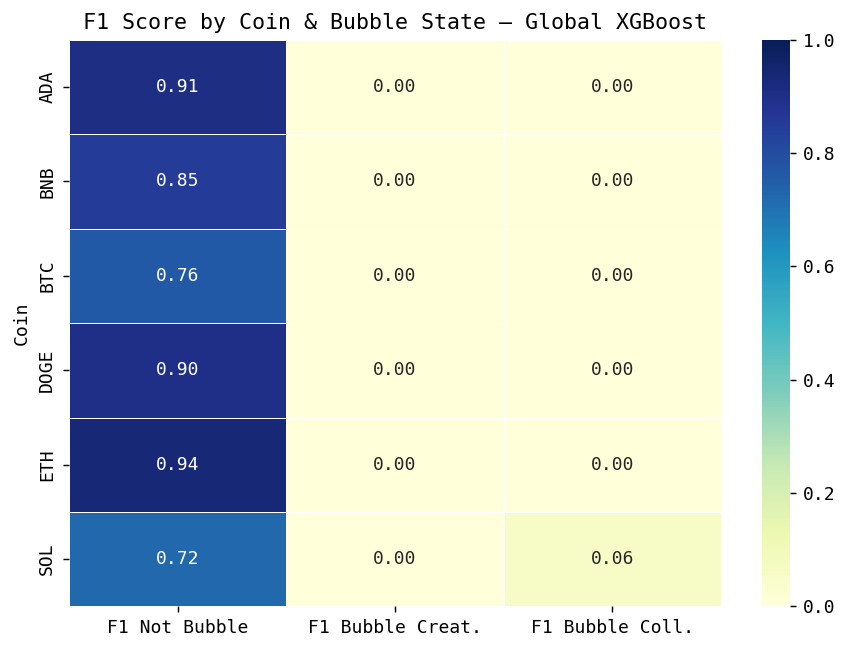


  MODEL 2 — PER-COIN (separate model for each coin)

───────────────────────────────────────────────────────
  Training per-coin model : ADA
───────────────────────────────────────────────────────
  Train: 1,949  |  Test: 488  | Cut-off: 2023-09-01
SMOTE  Before: {'Not Bubble': 1536, 'Bubble Creation': 255, 'Bubble Collapse': 158}  →  After: {'Not Bubble': 1536, 'Bubble Creation': 1536, 'Bubble Collapse': 1536}
  Best CV macro-F1 : 0.9926
  Per-Coin: ADA
  ⚠ Only 2 class(es) in test set: ['Not Bubble', 'Bubble Creation']
                 precision    recall  f1-score   support

     Not Bubble     0.8476    1.0000    0.9175       406
Bubble Creation     1.0000    0.1098    0.1978        82
Bubble Collapse     0.0000    0.0000    0.0000         0

       accuracy                         0.8504       488
      macro avg     0.6159    0.3699    0.3718       488
   weighted avg     0.8732    0.8504    0.7966       488

  Macro F1   : 0.5577   |   Weighted F1 : 0.7966   |   ROC-AUC : 0.930

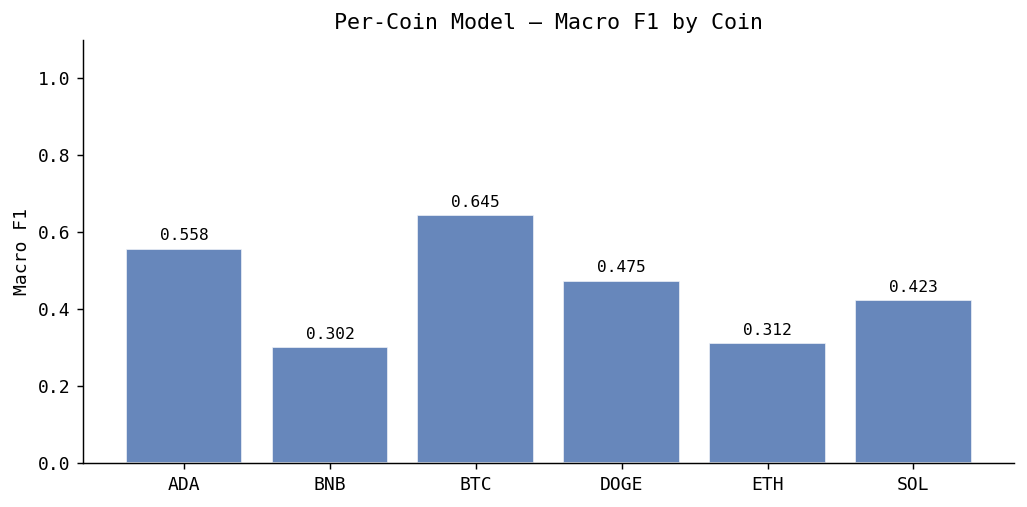

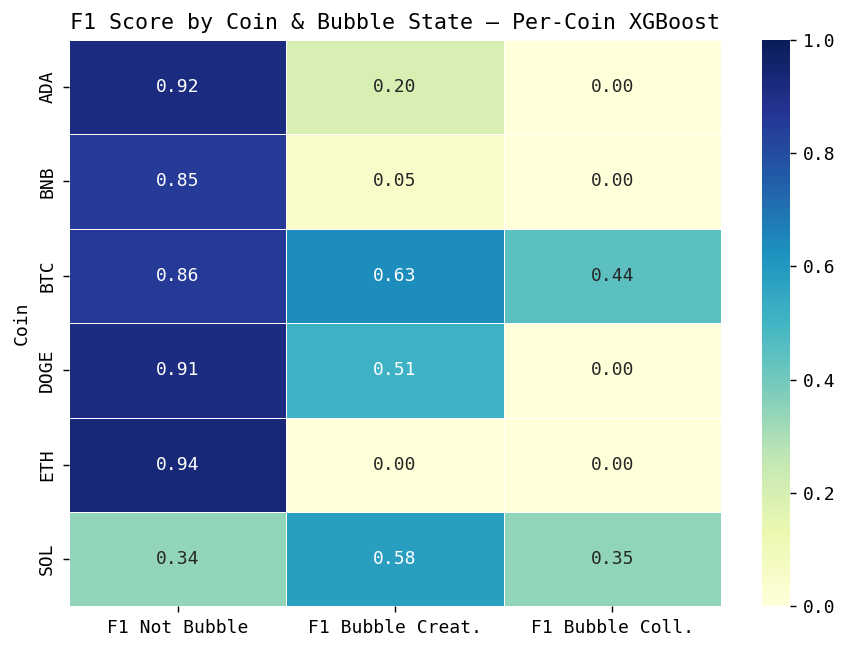

Metrics saved → xgboost_stats_fixed\model_metrics_summary.csv

  RESULTS SUMMARY
  Global Model    — Macro F1 : 0.2922  | ROC-AUC : 0.7901
  Per-Coin Models — Avg Macro F1 : 0.4524
    ADA    : Macro F1 0.5577  | ROC-AUC 0.9306
    BNB    : Macro F1 0.3023  | ROC-AUC 0.8603
    BTC    : Macro F1 0.6447  | ROC-AUC 0.9159
    DOGE   : Macro F1 0.4748  | ROC-AUC 0.8853
    ETH    : Macro F1 0.3119  | ROC-AUC 0.7596
    SOL    : Macro F1 0.4233  | ROC-AUC 0.8715

All outputs saved to xgboost_stats/


In [9]:
def main(filepath: str = "data/df_features_with_labels.csv"):
    """
    End-to-end pipeline.

    Model 1 — Global XGBoost
      1. Load & preprocess all coins together
      2. Chronological train/test split (all coins share the same date cutoff)
      3. SMOTE on the combined training set
      4. Hyperparameter tuning → train → evaluate

    Model 2 — Per-Coin XGBoost
      For each coin independently:
      1. Filter to that coin's rows
      2. Chronological split within the coin
      3. SMOTE on that coin's training set
      4. Hyperparameter tuning → train → evaluate
    """

    # Aesthetic header
    print("=" * 60)
    print("  DSE4211 GROUP 18 — XGBoost Bubble Prediction Pipeline")
    print("=" * 60 + "\n")

    # 1. Load the data and preprocess (encode, impute, create lead label) 
    df = load_and_preprocess(filepath)

    # 2. MODEL 1 — GLOBAL (all coins combined)
    print("\n" + "=" * 60)
    print("  MODEL 1 — GLOBAL (all coins combined)")
    print("=" * 60)

    X_train, X_test, y_train, y_test, df_train, df_test = \
        temporal_train_test_split(df, test_ratio=0.2)

    # ── FIX 3: Apply SMOTE per-coin within the global training set.
    #           Applying SMOTE to the combined multi-coin set lets the algorithm
    #           create synthetic minority samples by interpolating between feature
    #           vectors from *different* coins, producing unrealistic combinations
    #           (e.g. a synthetic "Bubble Creation" sample that blends BTC and ADA
    #           price dynamics). Oversampling each coin independently keeps
    #           synthetic samples within the same coin's feature distribution. ──
    smote_parts_X, smote_parts_y = [], []
    for _coin in sorted(df_train["symbol"].unique()):
        _mask = df_train["symbol"] == _coin
        _Xc, _yc = split_features_target(df_train[_mask])
        if _yc.nunique() < 2:
            smote_parts_X.append(_Xc)
            smote_parts_y.append(_yc)
            continue
        _Xr, _yr = apply_smote(_Xc, _yc, verbose=False)
        smote_parts_X.append(pd.DataFrame(_Xr, columns=_Xc.columns))
        smote_parts_y.append(pd.Series(_yr))
    X_tr_res = pd.concat(smote_parts_X, ignore_index=True)
    y_tr_res = pd.concat(smote_parts_y, ignore_index=True)
    y_before = y_train.copy()
    plot_class_distribution(y_before, y_tr_res, " (Global)")

    print("\nHyperparameter tuning — Global model...")
    global_model = hyperparameter_tuning(X_tr_res, y_tr_res, n_iter=40, cv_folds=5)
    # train_model now carves its own val set — no test set passed in
    global_model = train_model(X_tr_res, y_tr_res, global_model)
    res_global   = evaluate_model(global_model, X_test, y_test, "Global XGBoost")

    ## 2.1 Global model plots
    plot_confusion_matrix(y_test, res_global["y_pred"], "Global XGBoost")
    plot_per_class_metrics(res_global)
    plot_feature_importance(global_model, model_name="Global XGBoost", top_n=20)

    ## 2.2 Cross-asset view: how does the global model perform on each coin?
    print("\nGlobal model — per-coin breakdown:")
    df_global_coins = evaluate_per_coin(global_model, df_test, "Global XGBoost")
    print(df_global_coins.to_string(index=False))
    plot_per_coin_heatmap(df_global_coins, title="Global XGBoost")

    # 3. MODEL 2 — PER-COIN MODELS
    print("\n" + "=" * 60)
    print("  MODEL 2 — PER-COIN (separate model for each coin)")
    print("=" * 60)

    per_coin_models, per_coin_results, per_coin_summary = train_per_coin_models(
        df, test_ratio=0.2, n_iter=40, cv_folds=5
    )

    ## 3.1 Per-coin models plots
    plot_per_coin_model_comparison(per_coin_results)

    ## 3.2  Per-coin heatmap using each coin's own model predictions
    per_coin_f1_rows = []
    for coin, result in per_coin_results.items():
        per_coin_f1_rows.append({
            "Coin"             : coin,
            "F1 Not Bubble"    : round(result["f1_per_class"][0], 4),
            "F1 Bubble Creat." : round(result["f1_per_class"][1], 4),
            "F1 Bubble Coll."  : round(result["f1_per_class"][2], 4),
            "F1 Weighted"      : round(result["f1_weighted"],      4),
        })
    df_per_coin_f1 = pd.DataFrame(per_coin_f1_rows)
    plot_per_coin_heatmap(df_per_coin_f1, title="Per-Coin XGBoost")

    # 4. EXPORT ALL METRICS TO CSV
    all_results = [res_global] + list(per_coin_results.values())
    export_metrics_to_csv(all_results)

    # 5. FINAL SUMMARY PRINT-OUT
    print("\n" + "=" * 60)
    print("  RESULTS SUMMARY")
    print("=" * 60)
    print(f"  Global Model    — Macro F1 : {res_global['f1_macro']:.4f}  "
          f"| ROC-AUC : {res_global['roc_auc']:.4f}")
    if per_coin_results:
        avg_f1 = np.mean([r["f1_macro"] for r in per_coin_results.values()])
        print(f"  Per-Coin Models — Avg Macro F1 : {avg_f1:.4f}")
        for coin, r in per_coin_results.items():
            print(f"    {coin:<6} : Macro F1 {r['f1_macro']:.4f}  "
                  f"| ROC-AUC {r['roc_auc']:.4f}")
    print("=" * 60)
    print("\nAll outputs saved to xgboost_stats/")
    return global_model, per_coin_models


# Start the pipeline
if __name__ == "__main__":
    FILEPATH = "data/df_features_with_labels.csv"
    global_model, per_coin_models = main(FILEPATH)
